# 2D solid harmonic wavelet validation

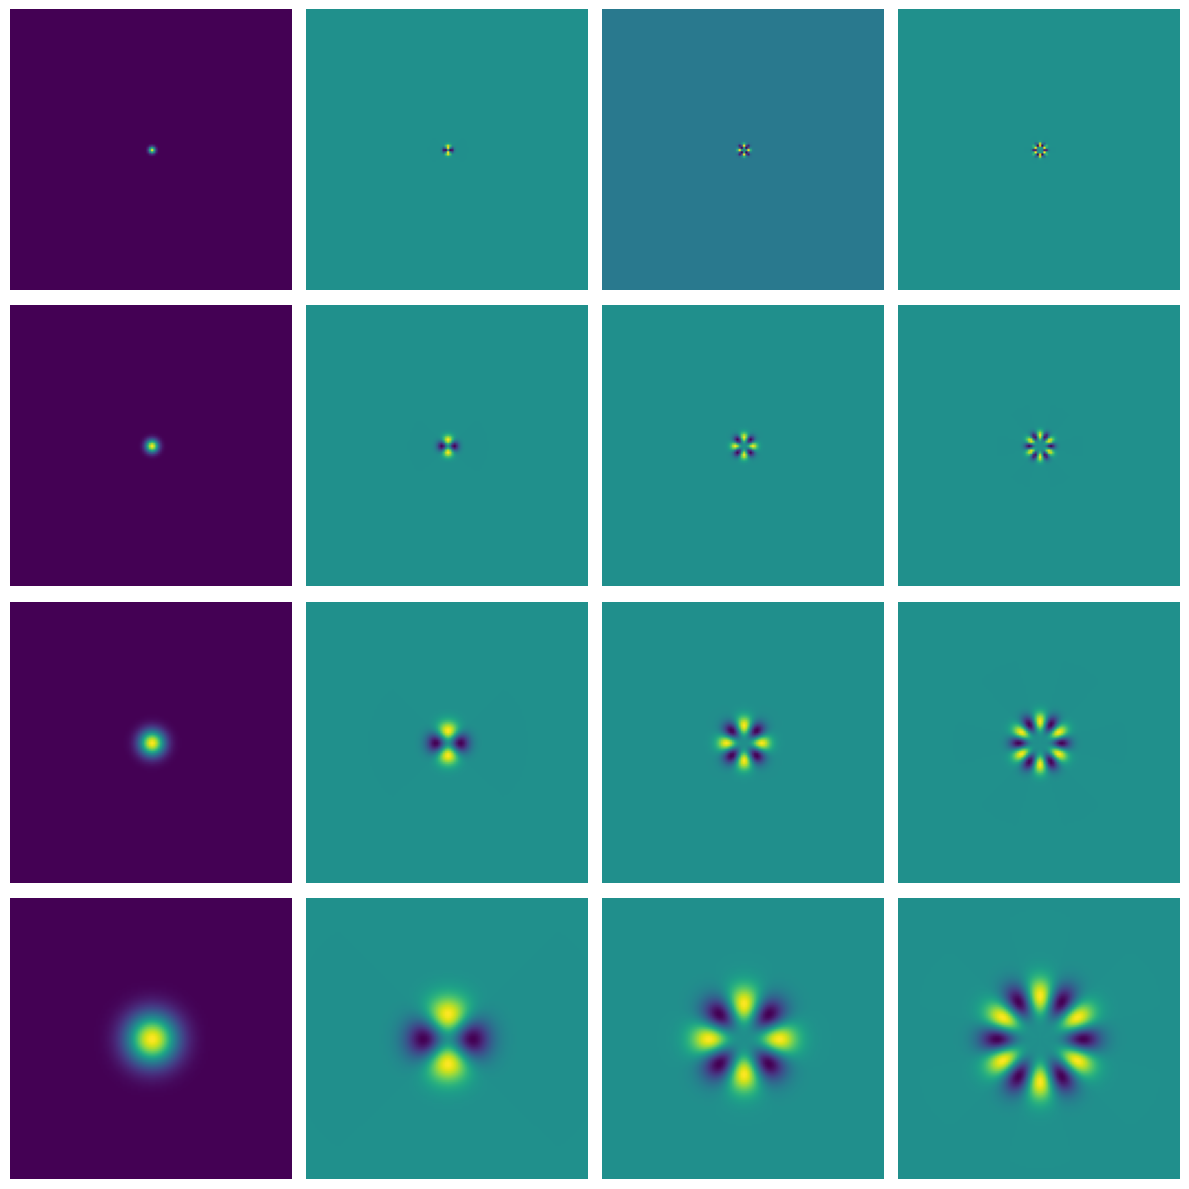

In [4]:
import glob

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from scipy.ndimage import rotate

from wavelets import solid_harmonic_filter_bank, solid_harmonic_2d

L, J = 10, 3
M, N = 128, 128
sigma_0 = 1
filters = solid_harmonic_filter_bank(M, N, J, L, sigma_0, fourier=False)

fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for idx, l in enumerate([0, 2, 4, 6]):
    for j in range(0, J + 1):
        wavelet = filters[l][j]
        ax = axs[j, idx]
        ax.axis('off')
        ax.imshow(np.real(wavelet), cmap="viridis")

plt.tight_layout()
plt.show()

# Testing

In [5]:
def rotate_image(image, angle):
    return rotate(image, angle, reshape=False, mode="nearest")


def apply_wavelet(image, wavelet):
    img_fourier = np.fft.fft2(image)
    return img_fourier * wavelet

In [22]:
euclid = glob.glob("../datasets/euclid/*.fits")
galim = fits.open(euclid[42])
sample_img = galim[0].data

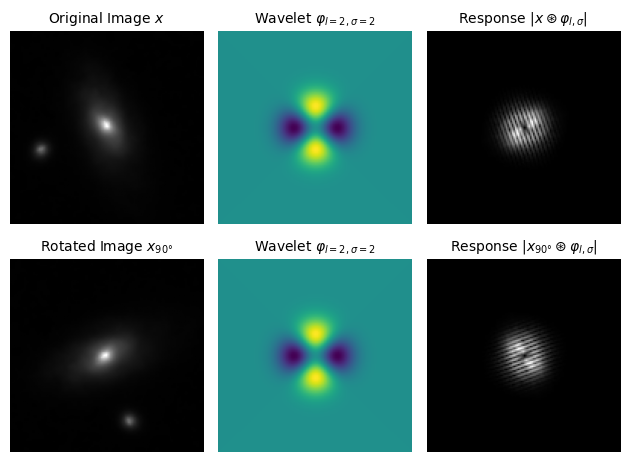

In [24]:
some_wavelet = solid_harmonic_2d(sample_img.shape[0], sample_img.shape[1], 2, 2, fourier=True)
original = apply_wavelet(sample_img, some_wavelet)
rotated = rotate_image(sample_img, 90)
rotated_convolved = apply_wavelet(rotated, some_wavelet)

fig, axs = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0, hspace=0)

axs[0, 0].imshow(sample_img, cmap="gray")
axs[0, 0].axis("off")
axs[0, 0].set_title(r"Original Image $x$", fontsize=10)

axs[0, 1].imshow(np.real(np.fft.fftshift(some_wavelet)))
axs[0, 1].axis("off")
axs[0, 1].set_title(r"Wavelet $\varphi_{l=2, \sigma=2}$", fontsize=10)

axs[0, 2].imshow(np.abs(np.fft.fftshift(original)), cmap="gray")
axs[0, 2].axis("off")
axs[0, 2].set_title(r"Response $|x \circledast \varphi_{l, \sigma}|$", fontsize=10)

axs[1, 0].imshow(rotated, cmap="gray")
axs[1, 0].axis("off")
axs[1, 0].set_title(r"Rotated Image $x_{90°}$", fontsize=10)

axs[1, 1].imshow(np.real(np.fft.fftshift(some_wavelet)))
axs[1, 1].axis("off")
axs[1, 1].set_title(r"Wavelet $\varphi_{l=2, \sigma=2}$", fontsize=10)

axs[1, 2].imshow(np.abs(np.fft.fftshift(rotated_convolved)), cmap="gray")
axs[1, 2].axis("off")
axs[1, 2].set_title(r"Response $|x_{90°} \circledast \varphi_{l, \sigma}|$", fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
def test_normalization(fourier, verbose=False):
    M, N = 64, 64
    for sigma in [1, 1.5, 2, 2.5, 3.0, 3.5, 4.0]:
        for l in range(0, 8):
            wavelet = solid_harmonic_2d(M, N, sigma, l, fourier=fourier)
            norm = np.linalg.norm(wavelet)
            normalized_norm = norm / np.sqrt(M * N)
            if fourier:
                if verbose: print(f"l={l}, norm={normalized_norm}")
                assert np.isclose(normalized_norm, 1.0, atol=1e-1)
            else:
                if verbose: print(f"l={l}, norm={norm}")
                assert np.isclose(norm, 1.0, atol=1e-1)


def test_zero_mean():
    M, N = 64, 64
    sigma = 1.0
    for l in [1, 2, 3, 4, 5, 6, 7]:
        wavelet = solid_harmonic_2d(M, N, sigma, l, fourier=False)
        assert np.isclose(np.sum(wavelet.real), 0.0, atol=1e-4)
        assert np.isclose(np.sum(wavelet.imag), 0.0, atol=1e-4)


test_zero_mean()
print("--- ZERO MEAN PASSED ---")

test_normalization(fourier=True, verbose=False)
print("--- UNIT ENERGY FOURIER DOMAIN PASSED ---")

test_normalization(fourier=False, verbose=False)
print("--- UNIT ENERGY SPATIAL DOMAIN PASSED ---")

--- ZERO MEAN PASSED ---
--- UNIT ENERGY FOURIER DOMAIN PASSED ---
--- UNIT ENERGY SPATIAL DOMAIN PASSED ---
